# Chirped LGS

> Simulate a chirped sodium LGS beacon

In [1]:
from pylgs.lgssystem import LGSSystem
import numpy as np

In [2]:
lgs = LGSSystem(
    'NaD2_Repump', 
    dict(
        # Repump beam parameters
        EllipticityDegrees1=45.,
        PolarizationAngleDegrees1=0,
        # 'DetuningHz1=1.0832e9,
        LaserWidthHz1=10.0e6,
        IntensitySI1=.2 * 75.,

        # Pump beam parameters
        EllipticityDegrees2=45.,
        PolarizationAngleDegrees2=0,
        # 'DetuningHz2=-6.268e8,
        LaserWidthHz2=10.0e6,
        IntensitySI2=.8 * 75.,

        # Environmental parameters
        BFieldG=.5,
        MagneticZenithDegrees=45.,
        MagneticAzimuthDegrees=45.,
        SDampingCollisionRatePerS=4081.63,
        BeamTransitRatePerS=131.944,
        VccRatePerS=28571.,
        TemperatureK=185.,
        RecoilParameter=1
    )
)

In [9]:
%%time
mu = dict(nu=2*np.pi*4e3)
model, sol = lgs.adaptive_stationary_floquet_model(
    dict(
        DetuningHz1="1.0832e9 + 1200e3 * t", 
        DetuningHz2="-6.268e8 + 1200e3 * t"
    ),
    mu,
    np.linspace(0, 1e-3, 500),
    n_vector=10,
    max_weight=.1
)

Creating model with 6 velocity groups
Solving model
Creating model with 12 velocity groups
Solving model
Creating model with 18 velocity groups
Solving model
Creating model with 24 velocity groups
Solving model
Creating model with 36 velocity groups
Solving model
CPU times: user 5min 11s, sys: 9.72 s, total: 5min 21s
Wall time: 5min 18s


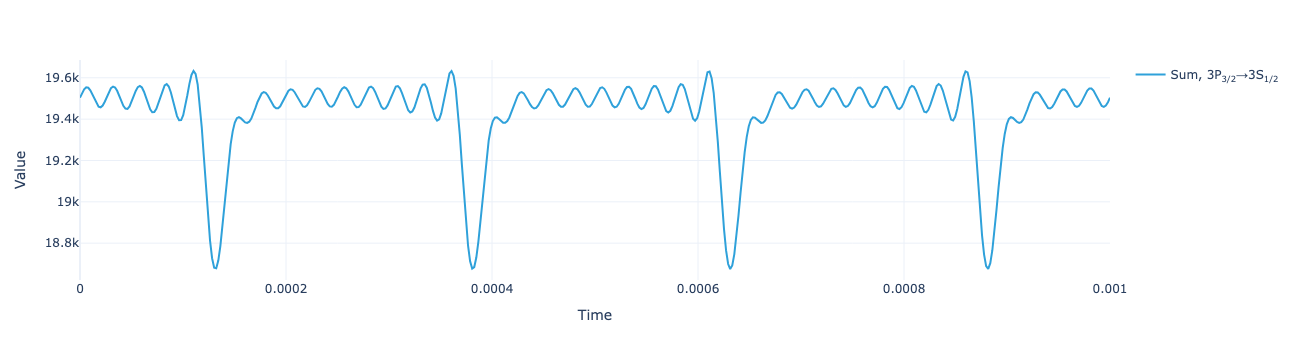

In [10]:
model.reconstructed_total_flux(sol, mu).real.visualize()

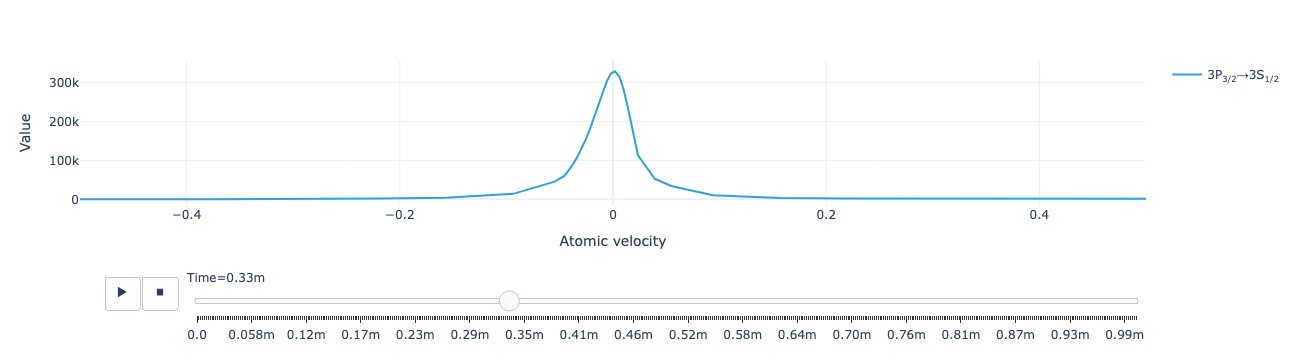

In [11]:
model.reconstructed_flux_distribution(sol, mu).real.visualize(xaxis_range=(-.5, .5))

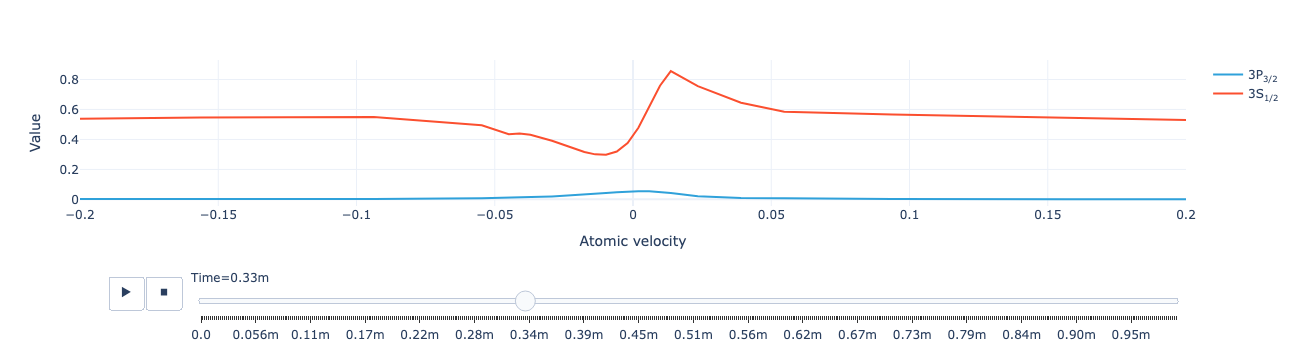

In [12]:
model.level_population_distribution(model.reconstruct(sol, mu)).real.visualize(xaxis_range=(-.2, .2))